In [ ]:
import importlib
import scraper as sc
importlib.reload(sc)
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
import ssl
import pandas as pd

try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

nltk.download('punkt')

plt.style.use('ggplot')

In [ ]:
nsdq = sc.nsdq_tickers("nasdaq.csv")
posts_df = sc.fetch_submissions("wallstreetbets", 100)
posts_df = sc.post_extract_tickers(posts_df, nsdq)
posts_df.head(50)

In [ ]:
cmts = sc.fetch_top_comments("1ndwms0")
cmts

In [4]:
sample = posts_df["content"][1]
tokens = nltk.word_tokenize(sample)
tagged = nltk.pos_tag(tokens)
entities = nltk.chunk.ne_chunk(tagged)

In [11]:
from nltk.sentiment import SentimentIntensityAnalyzer
from tqdm import tqdm

sia = SentimentIntensityAnalyzer()

In [12]:
sia.polarity_scores(sample)

{'neg': 0.0, 'neu': 0.575, 'pos': 0.425, 'compound': 0.5719}

In [26]:
res = {}
for i, row in tqdm(posts_df.iterrows(), total = len(posts_df)):
    text = row["content"]
    sub_id = row["submission_id"]
    
    res[sub_id] = sia.polarity_scores(text)


100%|██████████| 52/52 [00:00<00:00, 2283.91it/s]


In [ ]:
vaders = pd.DataFrame(res).T
vaders = vaders.reset_index().rename(columns={'index':'submission_id'})
vaders = vaders.merge(posts_df, how='left')
vaders

In [46]:
cmt_scores = {}
for i, row in tqdm(posts_df.iterrows(), total=len(posts_df)):
    cmts_df = sc.fetch_top_comments(row["submission_id"])
    if cmts_df.empty:
        avg_compound = None
    else:
        cmts_df["compound"] = cmts_df["body"].apply(lambda x: sia.polarity_scores(x)["compound"])
        avg_compound = cmts_df["compound"].mean()
    cmt_scores[row["submission_id"]] = avg_compound

comment_scores_df = pd.DataFrame.from_dict(cmt_scores, orient = 'index', columns = ["c_compound"])
comment_scores_df = comment_scores_df.reset_index().rename(columns = {'index' : 'submission_id'})
merged = vaders.merge(comment_scores_df, on='submission_id', how='right')

100%|██████████| 52/52 [00:34<00:00,  1.52it/s]


In [ ]:
merged

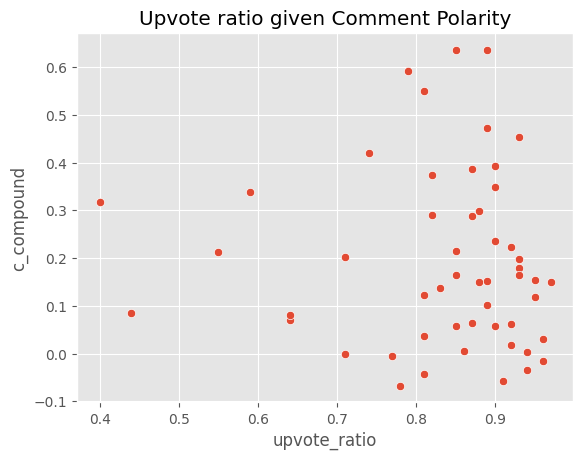

In [61]:
axis = sns.scatterplot(data = merged, x = 'upvote_ratio', y = 'c_compound')
axis.set_title("Upvote ratio given Comment Polarity")
plt.show()